In [14]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


awards_path = 'merged_awards_festival_wide_data.csv'
imdb_path = '3_imdb-dataset_general-info_wide.csv'

df_awards = pd.read_csv(awards_path, low_memory=False)
df_imdb = pd.read_csv(imdb_path, low_memory=False)

agg_dict = {
    'awards.nom.win': lambda x: 1 if 'Winner' in x.values else 0,
    'imdb.id': 'first',
    'prod.year': 'first',
    'title.mixed': 'first',
    'length.min': 'first',
    'genre': 'first',
    'prod.country.1.en': 'first',
    'fest.first': 'first',
    'animt': 'first',
    'doc': 'first',
    'exp': 'first',
    'fict': 'first',
    'regions.la': 'first',
    'regions.eu': 'first',
    'regions.na': 'first'
}

df_movie = df_awards.groupby('unique.id').agg(agg_dict).reset_index()
df_movie.rename(columns={'awards.nom.win': 'is_winner'}, inplace=True)

def clean_currency(x):
    """Parses currency strings like '$1,234,567' or '123,456' into floats."""
    if pd.isna(x) or str(x) == 'NA': 
        return np.nan
    match = re.search(r'[\d,]+', str(x))
    if match:
        return float(match.group(0).replace(',', ''))
    return np.nan

df_imdb['grossWorld_clean'] = df_imdb['grossWorld'].apply(clean_currency)

df_imdb_dedup = df_imdb.sort_values('grossWorld_clean', ascending=False).drop_duplicates(subset=['imdb.id'])


merged_df = pd.merge(df_movie, df_imdb_dedup[['imdb.id', 'grossWorld_clean']], on='imdb.id', how='left')

df_filtered = merged_df[merged_df['grossWorld_clean'] > 0].copy()

print(f"Original Movie Count: {len(df_movie)}")
print(f"Filtered Movie Count (with World Gross): {len(df_filtered)}")


df_clean = df_filtered.dropna(subset=['genre']).copy()
df_clean['prod.year'] = df_clean['prod.year'].fillna(df_clean['prod.year'].median())
df_clean['length.min'] = df_clean['length.min'].fillna(df_clean['length.min'].median())
df_clean['prod.country.1.en'] = df_clean['prod.country.1.en'].fillna('Unknown')

top_countries = df_clean['prod.country.1.en'].value_counts().nlargest(10).index
df_clean['country_group'] = df_clean['prod.country.1.en'].apply(lambda x: x if x in top_countries else 'Other')

target = 'is_winner'
numeric_features = ['prod.year', 'length.min', 'grossWorld_clean']
categorical_features = ['genre', 'fest.first', 'country_group']
binary_features = ['animt', 'doc', 'exp', 'fict', 'regions.la', 'regions.eu', 'regions.na']

X = df_clean[numeric_features + categorical_features + binary_features]
y = df_clean[target]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('bin', 'passthrough', binary_features)
    ])

clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


ohe_feature_names = clf.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_feature_names) + binary_features


coefficients = clf.named_steps['classifier'].coef_[0]

feature_importance = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefficients})
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print("\nTop 10 Most Important Features:\n", feature_importance.head(10))

Original Movie Count: 9348
Filtered Movie Count (with World Gross): 2286

Accuracy Score: 0.5655021834061136

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.59      0.35        92
           1       0.84      0.56      0.67       366

    accuracy                           0.57       458
   macro avg       0.55      0.57      0.51       458
weighted avg       0.72      0.57      0.61       458


Top 10 Most Important Features:
                          Feature  Coefficient  Abs_Coefficient
2               grossWorld_clean     1.682599         1.682599
29                    regions.la     1.383839         1.383839
10   fest.first_CLERMONT-FERRAND     1.330773         1.330773
17          country_group_France    -0.813848         0.813848
16           country_group_China     0.811834         0.811834
20           country_group_Japan    -0.640371         0.640371
23  country_group_United Kingdom    -0.545737         0.545737
2

/var/folders/n6/bsk7z2p97mj4mgj63qc9zg1m0000gn/T/ipykernel_91602/2126508717.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


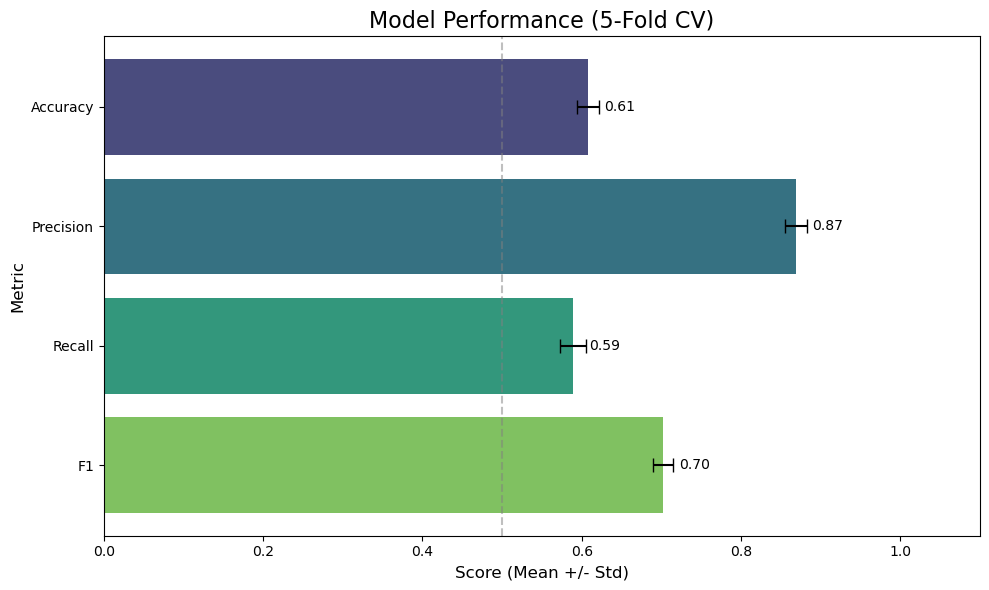

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('bin', 'passthrough', binary_features)
    ])

clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']

results_data = []
for metric in scoring_metrics:
    scores = cross_val_score(clf, X, y, cv=cv, scoring=metric)
    results_data.append({
        'Metric': metric.capitalize(), 
        'Score': scores.mean(), 
        'Std': scores.std()
    })

results_df = pd.DataFrame(results_data)


plt.figure(figsize=(10, 6))


sns.barplot(
    x='Score', 
    y='Metric', 
    data=results_df, 
    palette='viridis'
)


plt.errorbar(
    x=results_df['Score'], 
    y=range(len(results_df)), 
    xerr=results_df['Std'], 
    fmt='none', 
    c='black', 
    capsize=5
)


plt.title('Model Performance (5-Fold CV)', fontsize=16)
plt.xlabel('Score (Mean +/- Std)', fontsize=12)
plt.ylabel('Metric', fontsize=12)
plt.xlim(0, 1.1) 
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)


for index, row in results_df.iterrows():
    plt.text(row['Score'] + 0.02, index, f"{row['Score']:.2f}", color='black', va='center')

plt.tight_layout()
plt.show()

Data ready. Movies: 2286, Winners: 1792 (78.4%)

--- Cross-Validation Results ---


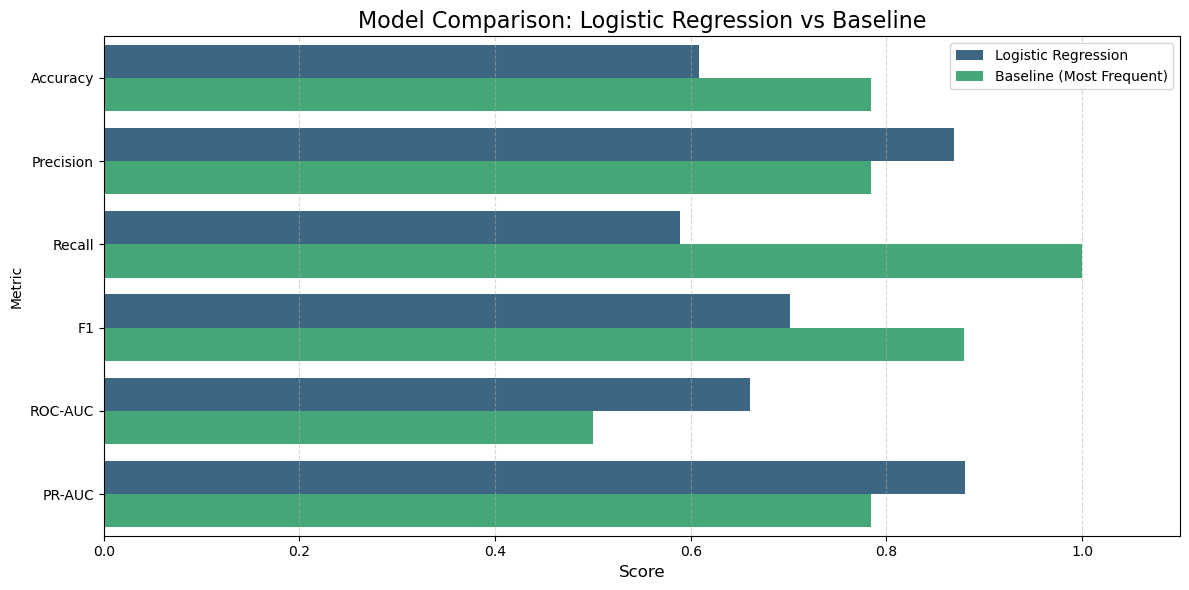


Comparison chart saved as 'model_baseline_comparison.png'


In [18]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


df_awards = pd.read_csv('merged_awards_festival_wide_data.csv', low_memory=False)
df_imdb = pd.read_csv('3_imdb-dataset_general-info_wide.csv', low_memory=False)


agg_dict = {
    'awards.nom.win': lambda x: 1 if 'Winner' in x.values else 0,
    'imdb.id': 'first',
    'prod.year': 'first',
    'title.mixed': 'first',
    'length.min': 'first',
    'genre': 'first',
    'prod.country.1.en': 'first',
    'fest.first': 'first',
    'animt': 'first', 'doc': 'first', 'exp': 'first', 'fict': 'first',
    'regions.la': 'first', 'regions.eu': 'first', 'regions.na': 'first'
}
df_movie = df_awards.groupby('unique.id').agg(agg_dict).reset_index()
df_movie.rename(columns={'awards.nom.win': 'is_winner'}, inplace=True)

def clean_currency(x):
    if pd.isna(x) or str(x) == 'NA': return np.nan
    match = re.search(r'[\d,]+', str(x))
    if match: return float(match.group(0).replace(',', ''))
    return np.nan

df_imdb['grossWorld_clean'] = df_imdb['grossWorld'].apply(clean_currency)

df_imdb_dedup = df_imdb.sort_values('grossWorld_clean', ascending=False).drop_duplicates(subset=['imdb.id'])

merged_df = pd.merge(df_movie, df_imdb_dedup[['imdb.id', 'grossWorld_clean']], on='imdb.id', how='left')

df_clean = merged_df[merged_df['grossWorld_clean'] > 0].copy()

df_clean['prod.year'] = df_clean['prod.year'].fillna(df_clean['prod.year'].median())
df_clean['length.min'] = df_clean['length.min'].fillna(df_clean['length.min'].median())
df_clean['prod.country.1.en'] = df_clean['prod.country.1.en'].fillna('Unknown')

top_countries = df_clean['prod.country.1.en'].value_counts().nlargest(10).index
df_clean['country_group'] = df_clean['prod.country.1.en'].apply(lambda x: x if x in top_countries else 'Other')


target = 'is_winner'
numeric_features = ['prod.year', 'length.min', 'grossWorld_clean']
categorical_features = ['genre', 'fest.first', 'country_group']
binary_features = ['animt', 'doc', 'exp', 'fict', 'regions.la', 'regions.eu', 'regions.na']

X = df_clean[numeric_features + categorical_features + binary_features]
y = df_clean[target]

print(f"Data ready. Movies: {len(X)}, Winners: {y.sum()} ({y.mean():.1%})")


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('bin', 'passthrough', binary_features)
    ])


clf_log = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])


clf_dummy = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']

results_data = []
models = {'Logistic Regression': clf_log, 'Baseline (Most Frequent)': clf_dummy}

print("\n--- Cross-Validation Results ---")


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']

results_data = []
models = {'Logistic Regression': clf_log, 'Baseline (Most Frequent)': clf_dummy}

for model_name, model in models.items():
    for metric in scoring_metrics:
        scores = cross_val_score(model, X, y, cv=cv, scoring=metric)
        results_data.append({
            'Model': model_name,
            'Metric': metric.replace('_', ' ').title().replace('Roc Auc', 'ROC-AUC').replace('Average Precision', 'PR-AUC'),
            'Score': scores.mean()
        })

results_df = pd.DataFrame(results_data)

plt.figure(figsize=(12, 6))
sns.barplot(x='Score', y='Metric', hue='Model', data=results_df, palette='viridis')
plt.title('Model Comparison: Logistic Regression vs Baseline', fontsize=16)
plt.xlabel('Score', fontsize=12)
plt.xlim(0, 1.1)
plt.legend(loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.savefig('model_baseline_comparison.png')
plt.show()

print("\nComparison chart saved as 'model_baseline_comparison.png'")